<div dir="rtl">
  <h2>מטלת סיכום בלמידת מכונה – חלק 2: מודל חיזוי דירוג סרטים</h2>
  <h3>קורס למידת מכונה</h3>
  
  <p>
    <strong>מגישות:</strong><br>
    מרים דינאי 212296099<br>
    הילה הלברטשטט 032540668
  </p>

  <p>
    <strong>GitHub:</strong><br>
    <span dir="ltr"><a href="https://github.com/MiriamDinay/Movie-Data-Collection-Project2">https://github.com/MiriamDinay/Movie-Data-Collection-Project2</a></span>
  </p>
</div>

In [1]:
import pandas as pd
import numpy as np

<h4 dir="rtl">הגדרת פונקציית prepare_data</h4>

<p dir="rtl">
יצירת פונקציה <code>prepare_data</code> שמטרתה ניקוי והכנת קובץ נתונים של סרטים לצורך אימון המודל, תוך הסרת עמודות שעלולות לגרום לזליגת מידע (<code>Data Leakage</code>) וטיפול בערכים חסרים.<br>
בנוסף, הפונקציה מבצעת <code>Feature Engineering</code> על ידי חילוץ מאפיינים חדשים מתוך הטקסט והתאריכים, כמו זיהוי מדינת הסרט, אורך התקציר וסיווג ז'אנרים.
</p>

In [2]:
def prepare_data(df):
    data = df.copy()
    data.columns = data.columns.str.strip()

    leakage_cols = ['averageRating', 'numVotes', 'BoxOffice']
    data = data.drop(columns=[c for c in leakage_cols if c in data.columns], errors='ignore')

    if 'runtimeMinutes' in data.columns:
        data['runtimeMinutes'] = data['runtimeMinutes'].astype(str).replace(r'\N', np.nan)
        data['runtimeMinutes'] = pd.to_numeric(data['runtimeMinutes'], errors='coerce')

    if 'startYear' in data.columns:
        data['startYear'] = data['startYear'].astype(str).replace(r'\N', np.nan)
        data['startYear'] = pd.to_numeric(data['startYear'], errors='coerce')
        data.loc[data['startYear'] <= 0, 'startYear'] = np.nan

    if 'genres' in data.columns:
        data['genres'] = data['genres'].astype(str)
        data['genres'] = data['genres'].str.replace(r"[\[\]'\"]", '', regex=True)
        data['genres'] = data['genres'].replace(r'\N', np.nan)


    # פיצ'ר 1: מספר הז'אנרים של הסרט
    data['num_genres'] = data['genres'].apply(
        lambda x: len(str(x).split(',')) if pd.notnull(x) else 0
    )

    # פיצ'ר 2: הז'אנר הראשי
    data['primary_genre'] = data['genres'].apply(
        lambda x: str(x).split(',')[0].strip() if pd.notnull(x) else 'Unknown'
    )

    # פיצ'רים 3-5: זה סימון אם הסרט שייך לז'אנרים נפוצים
    data['is_drama'] = data['genres'].apply(
        lambda x: int('Drama' in str(x)) if pd.notnull(x) else 0
    )
    data['is_comedy'] = data['genres'].apply(
        lambda x: int('Comedy' in str(x)) if pd.notnull(x) else 0
    )
    data['is_documentary'] = data['genres'].apply(
        lambda x: int('Documentary' in str(x)) if pd.notnull(x) else 0
    )

    #פיצ'ר 6: האם הסרט מארה"ב
    if 'Country' in data.columns:
        data['is_US'] = data['Country'].apply(
            lambda x: int(any(c.strip() in ['US', 'USA', 'United States']
                              for c in str(x).split(','))) if pd.notnull(x) else 0
        )
    else:
        data['is_US'] = 0

    # פיצ'ר 7: מספר המדינות בהפקה
    if 'Country' in data.columns:
        data['num_countries'] = data['Country'].apply(
            lambda x: len(str(x).split(',')) if pd.notnull(x) and str(x) != r'\N' else 0
        )
    else:
        data['num_countries'] = 0

    # פיצ'ר 8: עשור היציאה
    data['release_decade'] = (data['startYear'] // 10) * 10

    # פיצ'ר 9: אורך התקציר במילים 
    if 'plot' in data.columns:
        data['plot_length'] = data['plot'].apply(
            lambda x: len(str(x).split()) if pd.notnull(x) and str(x) != r'\N' else 0
        )
    else:
        data['plot_length'] = 0

    data = data.replace([np.inf, -np.inf], np.nan)
    raw_cols_to_drop = ['tconst', 'primaryTitle', 'genres', 'lead_actors_ids',
                        'plot', 'Country', 'Language', 'budget']
    data = data.drop(columns=[c for c in raw_cols_to_drop if c in data.columns],
                     errors='ignore')

    return data

In [3]:
try:
    raw_df = pd.read_csv('dataset.csv')
    raw_df.columns = raw_df.columns.str.strip()
    print(f"מספר שורות גולמי: {raw_df.shape[0]}")

    df_clean = raw_df.dropna(subset=['averageRating']).copy()
    print(f"מספר שורות לאחר הסרת סרטים ללא דירוג: {df_clean.shape[0]}")

    y = df_clean['averageRating']
    X = prepare_data(df_clean)

    # print("\n1. סוגי הנתונים")
    # print(X.dtypes)

    # print("\n2. כמות ערכים חסרים בכל פיצ'ר")
    # print(X.isnull().sum())

    print("\nתצוגה מקדימה של X")
    display(X.head())


    # print("\n4. בדיקה על שורה בודדת")
    # single_row = raw_df.head(1).copy()
    # single_output = prepare_data(single_row)
    # print(f"שורה בודדת עברה בהצלחה")

except FileNotFoundError:
    print("שגיאה הקובץ 'dataset.csv' לא נמצא.")

C:\Users\user\AppData\Local\Temp\ipykernel_34456\196768150.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv('dataset.csv')


מספר שורות גולמי: 133884
מספר שורות לאחר הסרת סרטים ללא דירוג: 115560

תצוגה מקדימה של X


,startYear,runtimeMinutes,num_genres,primary_genre,is_drama,is_comedy,is_documentary,is_US,num_countries,release_decade,plot_length
0,1993.0,90.0,3,Crime,1,0,0,0,1,1990.0,0
1,2024.0,86.0,1,Drama,1,0,0,0,0,2020.0,0
4,2006.0,102.0,1,Comedy,0,1,0,0,0,2000.0,0
7,2011.0,85.0,3,Biography,0,0,1,0,0,2010.0,0
8,1993.0,170.0,1,Documentary,0,0,1,0,0,1990.0,0


In [4]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 115560 entries, 0 to 133883
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   startYear       115559 non-null  float64
 1   runtimeMinutes  115560 non-null  float64
 2   num_genres      115560 non-null  int64  
 3   primary_genre   115560 non-null  object 
 4   is_drama        115560 non-null  int64  
 5   is_comedy       115560 non-null  int64  
 6   is_documentary  115560 non-null  int64  
 7   is_US           115560 non-null  int64  
 8   num_countries   115560 non-null  int64  
 9   release_decade  115559 non-null  float64
 10  plot_length     115560 non-null  int64  
dtypes: float64(3), int64(7), object(1)
memory usage: 10.6+ MB


In [5]:
X.describe()

,startYear,runtimeMinutes,num_genres,is_drama,is_comedy,is_documentary,is_US,num_countries,release_decade,plot_length
count,115559.000000,115560.000000,115560.000000,115560.000000,115560.000000,115560.000000,115560.000000,115560.000000,115559.000000,115560.000000
mean,1997.477436,98.573183,1.898442,0.505884,0.288300,0.112617,0.171037,0.478981,1993.055755,78.535990
std,24.754381,22.346947,0.835018,0.499968,0.452974,0.316125,0.376543,0.584540,24.997058,242.180074
min,1904.000000,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1900.000000,0.000000
25%,1983.000000,85.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1980.000000,0.000000
50%,2007.000000,94.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2000.000000,0.000000
75%,2017.000000,107.000000,3.000000,1.000000,1.000000,0.000000,0.000000,1.000000,2010.000000,58.000000
max,2026.000000,300.000000,3.000000,1.000000,1.000000,1.000000,1.000000,13.000000,2020.000000,11662.000000


In [6]:
X['primary_genre'].value_counts().head(10)

primary_genre
Drama          33564
Comedy         27975
Action         13987
Documentary    10496
Crime           6390
Adventure       5132
Horror          5057
Biography       3700
Thriller        1615
Adult           1116
Name: count, dtype: int64

<h4 dir="rtl">Pipeline ואימון מודל Elastic Net</h4>

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import KFold, GridSearchCV, cross_validate, cross_val_predict,cross_val_score

In [8]:
numeric_cols = X.select_dtypes('number').columns.tolist()
categorical_cols = X.select_dtypes('object').columns.tolist()

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipe, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])

elastic_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', ElasticNet(random_state=42, max_iter=5000))
])

<p dir="rtl">
הקוד מבצע תהליך אופטימיזציה וכיוונון פרמטרים למודל <code>Elastic Net</code> באמצעות <code>GridSearchCV</code>, תוך שימוש בשיטת <code>10-Fold Cross Validation</code> להבטחת יציבות המודל. מטרת התהליך היא למצוא את שילוב הערכים המיטבי עבור <code>alpha</code> ו-<code>l1_ratio</code>, אשר יביא למיזעור שגיאת החיזוי של דירוג הסרטים וישפר את דיוק המערכת.
</p>

In [9]:
param_grid = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0],
    'model__l1_ratio': [0.2, 0.5, 0.8]
}

cv = KFold(n_splits=10, shuffle=True, random_state=42)

grid_search = GridSearchCV(elastic_pipe, param_grid, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X, y)

best_elastic_model = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

Best parameters: {'model__alpha': 0.01, 'model__l1_ratio': 0.2}


##### הערכת המודל הטוב ביותר על שלושת המדדים

In [10]:
scoring_metrics = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

cv_results = cross_validate(best_elastic_model, X, y, cv=cv, scoring=scoring_metrics)

rmse_scores = -cv_results['test_RMSE']
mae_scores = -cv_results['test_MAE']
r2_scores = cv_results['test_R2']

print(f"RMSE: {rmse_scores.mean():.4f} (± {rmse_scores.std():.4f})")
print(f"MAE:  {mae_scores.mean():.4f} (± {mae_scores.std():.4f})")
print(f"R²:   {r2_scores.mean():.4f} (± {r2_scores.std():.4f})")

RMSE: 1.1459 (± 0.0093)
MAE:  0.8783 (± 0.0064)
R²:   0.2143 (± 0.0065)


#### Random Forest

In [11]:
from sklearn.ensemble import RandomForestRegressor

In [12]:
rf_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=2))
])

In [13]:
param_grid_rf = {
    'model__n_estimators': [100],
    'model__max_depth': [10, 20],
    'model__min_samples_leaf': [5]
}

grid_search_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=1)
grid_search_rf.fit(X, y)

best_rf_model = grid_search_rf.best_estimator_
print("Best parameters:", grid_search_rf.best_params_)

Best parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}


In [14]:
# הערכת המודל הטוב ביותר ב-10-Fold CV על שלושת המדדים
rmse_scores_rf = -cross_val_score(best_rf_model, X, y, cv=cv,
                                   scoring='neg_root_mean_squared_error', n_jobs=1)
mae_scores_rf = -cross_val_score(best_rf_model, X, y, cv=cv,
                                  scoring='neg_mean_absolute_error', n_jobs=1)
r2_scores_rf = cross_val_score(best_rf_model, X, y, cv=cv, scoring='r2', n_jobs=1)

print(f"RMSE: {rmse_scores_rf.mean():.4f} (± {rmse_scores_rf.std():.4f})")
print(f"MAE:  {mae_scores_rf.mean():.4f} (± {mae_scores_rf.std():.4f})")
print(f"R²:   {r2_scores_rf.mean():.4f} (± {r2_scores_rf.std():.4f})")

RMSE: 1.1191 (± 0.0090)
MAE:  0.8540 (± 0.0063)
R²:   0.2506 (± 0.0064)


<h5 dir="rtl">סיכום ביצועים ובחירת המודל המוביל</h5>
<p dir="rtl">
מניתוח תוצאות ההערכה על פני שלושת המדדים, עולה כי מודל <code>Random Forest</code> מציג ביצועים עדיפים באופן מובהק על פני מודל <code>Elastic Net</code>. עדיפות זו באה לידי ביטוי בשגיאת חיזוי נמוכה יותר (מדדי <code>RMSE</code> ו-<code>MAE</code> נמוכים יותר) וכושר הסבר גבוה יותר של השונות בדאטה (מדד <code>R²</code> גבוה יותר). 
<br><br>
לאור יתרונות אלו, בחרנו להשתמש במודל ה-<code>Random Forest</code> כמודל הראשי להמשך הפרויקט, ועליו נבצע בשלבים הבאים את ניתוחי השגיאות המורחבים ובדיקות ההוגנות (Fairness Analysis).
</p>

<h4 dir="rtl">Error Analysis – ניתוח שגיאות</h4>
<p dir="rtl">
כדי לבצע ניתוח שגיאות ו-<code>Fairness Analysis</code> בצורה מהימנה, בחרנו להפיק תחזיות עבור שני המודלים בשיטת <code>out-of-fold</code> באמצעות הפונקציה <code>cross_val_predict</code>. 
<br><br>
בדרך זו, אנחנו מבטיחות שכל סרט מקבל תחזית ממודל שלא ראה אותו בכלל בזמן האימון. זה מונע מהמודל "לשנן" את הסרטים הספציפיים האלה, ועוזר לנו לקבל תמונת מצב אמיתית, נקייה ולא מוטה של השגיאות לקראת השלבים הבאים.
</p>

In [15]:
y_pred_elastic = cross_val_predict(best_elastic_model, X, y, cv=cv, n_jobs=1)
y_pred_rf = cross_val_predict(best_rf_model, X, y, cv=cv, n_jobs=1)

print(f"מספר תחזיות עבור כל מודל: {len(y_pred_elastic)}")

מספר תחזיות עבור כל מודל: 115560


##### חישוב שגיאות

In [16]:
errors_elastic = y_pred_elastic - y.values
errors_rf = y_pred_rf - y.values

results_df = df_clean.copy()
results_df['y_true'] = y.values
results_df['pred_elastic'] = y_pred_elastic
results_df['pred_rf'] = y_pred_rf
results_df['error_elastic'] = errors_elastic
results_df['error_rf'] = errors_rf

results_df['genres'] = (results_df['genres'].astype(str).str.replace(r"[\[\]'\"]", '', regex=True))

display(results_df[['primaryTitle', 'startYear', 'genres', 'y_true','pred_rf',
                    'error_rf']].head())

,primaryTitle,startYear,genres,y_true,pred_rf,error_rf
0,Johnny One Hundred Pesos,1993.0,"Crime,Drama,Thriller",6.6,5.781885,-0.818115
1,It Doesn't Matter,2024.0,Drama,6.1,6.120533,0.020533
4,"If You Love Me, Follow Me",2006.0,Comedy,6.1,5.573031,-0.526969
7,I Want My Name Back,2011.0,"Biography,Documentary,Music",7.0,7.254123,0.254123
8,Itgaber: Le triomphe sur soi,1993.0,Documentary,9.2,7.469439,-1.730561


<h4 dir="rtl">זיהוי וחילוץ Outliers</h4>
<p dir="rtl">
כחלק מניתוח השגיאות, נחלץ את 20 הסרטים עם פער החיזוי הגדול ביותר: 10 סרטים שבהם המודל נתן ציון גבוה בהרבה מהמציאות (<code>Overprediction</code>), ו-10 סרטים שבהם הציון שחזה היה נמוך מדי (<code>Underprediction</code>). 
<br><br>
הסתכלות על מקרי הקיצון האלו תעזור לנו לזהות דפוסים משותפים ולהבין אילו מאפיינים בדאטה גורמים למודל לטעות.
</p>

In [17]:
top_over_rf = results_df.nlargest(10, 'error_rf')
top_under_rf = results_df.nsmallest(10, 'error_rf')


print("10 הסרטים עם ה-OVERPREDICTION הגדול ביותר")
display(top_over_rf[['primaryTitle', 'startYear', 'genres', 'runtimeMinutes',
                     'Country', 'y_true', 'pred_rf', 'error_rf']])

print("\n" + "10 הסרטים עם ה-UNDERPREDICTION הגדול ביותר")
display(top_under_rf[['primaryTitle', 'startYear', 'genres', 'runtimeMinutes',
                      'Country', 'y_true', 'pred_rf', 'error_rf']])

10 הסרטים עם ה-OVERPREDICTION הגדול ביותר


,primaryTitle,startYear,genres,runtimeMinutes,Country,y_true,pred_rf,error_rf
12464,Justin Bieber: Always Believing,2012.0,"Documentary,Music",70.0,NaN,1.0,7.112786,6.112786
133563,Horseplay: The History of Horse Riding,2021.0,"Animation,Documentary",64.0,NaN,1.0,7.112413,6.112413
52582,Rape of the Soul,2006.0,"Documentary, History",140.0,NaN,1.7,7.710287,6.010287
16815,Kurz,2023.0,Documentary,88.0,NaN,1.2,7.182356,5.982356
10554,Jasenovac: Istina,2016.0,"Documentary,History,Mystery",61.0,NaN,1.4,7.261479,5.861479
96377,At the Back of the Screen,2020.0,"Documentary,Drama",188.0,United States,1.5,7.289138,5.789138
37806,Obama in NC: The Path to History,2010.0,Documentary,116.0,NaN,1.5,7.287977,5.787977
52638,Ramo Trip,2012.0,Documentary,119.0,NaN,1.4,7.181138,5.781138
45946,Play in the Gray,2009.0,"Biography,Comedy,Documentary",85.0,United States,1.3,7.051679,5.751679
72010,Tribalism Is Killing Us,2019.0,Documentary,110.0,NaN,1.3,7.027993,5.727993



10 הסרטים עם ה-UNDERPREDICTION הגדול ביותר


,primaryTitle,startYear,genres,runtimeMinutes,Country,y_true,pred_rf,error_rf
57344,Son-nim-1 Cheo-beon-jjae I-ya-gi,2011.0,"Horror,Thriller",83.0,NaN,9.1,4.243904,-4.856096
131379,Halloween Deluxe,2019.0,Horror,203.0,NaN,9.1,4.559786,-4.540214
36522,Oscuro by Rene Potter,2016.0,Horror,80.0,NaN,8.6,4.069281,-4.530719
71780,Action on NTV: Definitive Edition,2021.0,"Action, Comedy, Crime",90.0,NaN,9.4,5.036853,-4.363147
122228,Hell Squad 2: Fresh Meat,2024.0,Horror,95.0,NaN,8.9,4.564431,-4.335569
1119,Ice Nine Kills Presents: Welcome to Horrorwood,2024.0,Horror,76.0,NaN,8.4,4.084870,-4.315130
1984,Jefa De Jefas,2024.0,Action,82.0,NaN,9.2,4.955570,-4.244430
43454,Puli Vachindi Meka Chachindi,2021.0,Thriller,97.0,NaN,9.5,5.272232,-4.227768
84488,Zen Comedy,2023.0,Comedy,63.0,NaN,9.8,5.625117,-4.174883
103281,Brotherhood of Blades Kill Evil,2024.0,Action,84.0,NaN,9.1,4.955570,-4.144430


<h5 dir="rtl">השוואת שגיאות קיצון (Outliers) בין שני המודלים</h5>
<p dir="rtl">
כדי להעמיק את הניתוח, נבדוק האם שני המודלים מתקשים לחזות את אותם הסרטים. לשם כך, נחלץ את 20 מקרי הקיצון גם ממודל ה-<code>Elastic Net</code> וגם ממודל ה-<code>Random Forest</code> ונשווה ביניהם.
<br><br>
על ידי מציאת החפיפה בין קבוצות השגיאות של המודלים, נוכל להבין האם הקושי בחיזוי נובע מהמגבלות של מודל ספציפי, או שמא קיימים סרטים "בעייתיים" באופן מהותי בדאטה שלנו שכל מודל יתקשה להתמודד איתם.
</p>

In [18]:
top_over_elastic = results_df.nlargest(10, 'error_elastic')
top_under_elastic = results_df.nsmallest(10, 'error_elastic')
outliers_elastic = pd.concat([top_over_elastic, top_under_elastic])

top_over_rf = results_df.nlargest(10, 'error_rf')
top_under_rf = results_df.nsmallest(10, 'error_rf')
outliers_rf = pd.concat([top_over_rf, top_under_rf])

common_outliers = set(outliers_elastic.index) & set(outliers_rf.index)
only_elastic = set(outliers_elastic.index) - set(outliers_rf.index)
only_rf = set(outliers_rf.index) - set(outliers_elastic.index)

print("השוואת outliers בין Elastic Net ל-Random Forest")
print("-" * 30)
print(f"סרטים שמופיעים כ-outliers בשני המודלים: {len(common_outliers)}")
print(f"סרטים שהם outliers רק ב-Elastic Net: {len(only_elastic)}")
print(f"סרטים שהם outliers רק ב-Random Forest: {len(only_rf)}")

השוואת outliers בין Elastic Net ל-Random Forest
------------------------------
סרטים שמופיעים כ-outliers בשני המודלים: 12
סרטים שהם outliers רק ב-Elastic Net: 8
סרטים שהם outliers רק ב-Random Forest: 8


<h5 dir="rtl">בחינה צולבת: כשמודל אחד טועה בגדול, האם השני מצליח?</h5>
<p dir="rtl">
כדי להבין לעומק את היתרונות היחסיים של כל מודל, נבצע בדיקה צולבת (Cross-Examination): ניקח את 20 הסרטים שבהם מודל ה-<code>Random Forest</code> הציג את שגיאות הקיצון הגדולות ביותר, ונבדוק מה הייתה השגיאה הממוצעת של מודל ה-<code>Elastic Net</code> דווקא עליהם (ולהפך).
<br><br>
בדיקה זו תאפשר לנו לגלות האם המודלים חולקים את אותן Blind Spots, או שמודל אחד מצליח לתפוס דפוסים נכונים בסרטים שמכשילים לחלוטין את המודל השני. 
</p>

In [19]:
print("עבור 20 ה-outliers של Random Forest:")
print(f"MAE (Random Forest): {outliers_rf['error_rf'].abs().mean():.3f}")
print(f"MAE (Elastic Net):   {outliers_rf['error_elastic'].abs().mean():.3f}\n")

print("עבור 20 ה-outliers של Elastic Net:")
print(f"MAE (Elastic Net):   {outliers_elastic['error_elastic'].abs().mean():.3f}")
print(f"MAE (Random Forest): {outliers_elastic['error_rf'].abs().mean():.3f}")

עבור 20 ה-outliers של Random Forest:
MAE (Random Forest): 5.132
MAE (Elastic Net):   4.962

עבור 20 ה-outliers של Elastic Net:
MAE (Elastic Net):   5.173
MAE (Random Forest): 4.777


<h5 dir="rtl">בחינה פרטנית של שגיאות הקיצון (Elastic Net)</h5>
<p dir="rtl">
כדי להבין את טיב השגיאות מעבר למדדים הסטטיסטיים היבשים, נציג כעת את הנתונים המלאים של 20 הסרטים שהיוו את מקרי הקיצון עבור מודל ה-<code>Elastic Net</code>. 
<br><br>
התבוננות ישירה בטבלה מאפשרת לנו לחפש בעין מאפיינים ספציפיים של הסרטים (כמו ז'אנרים מסוימים או שנת יציאה) שעשויים להסביר את הקושי בחיזוי. בנוסף, צירפנו לטבלה את התחזיות והשגיאות של מודל ה-<code>Random Forest</code> עבור אותם סרטים, כדי שנוכל להשוות את ההתנהגות של שני המודלים ברמת הסרט הבודד.
</p>

In [21]:
# הצגה מפורטת של 20 ה-outliers של Elastic Net עם השגיאות של שני המודלים
print("20 ה-outliers של Elastic Net - השוואת שגיאות בין המודלים")
display(outliers_elastic[['primaryTitle', 'startYear', 'genres', 'y_true',
                          'pred_elastic', 'error_elastic',
                          'pred_rf', 'error_rf']].sort_values('error_elastic'))

20 ה-outliers של Elastic Net - השוואת שגיאות בין המודלים


,primaryTitle,startYear,genres,y_true,pred_elastic,error_elastic,pred_rf,error_rf
84488,Zen Comedy,2023.0,Comedy,9.8,5.223058,-4.576942,5.625117,-4.174883
104195,Borderline Forever,2021.0,"Adventure, Comedy, Fantasy",9.7,5.218615,-4.481385,5.648919,-4.051081
88282,Zuena,2022.0,Drama,10.0,5.615640,-4.384360,6.237838,-3.762162
57344,Son-nim-1 Cheo-beon-jjae I-ya-gi,2011.0,"Horror,Thriller",9.1,4.717086,-4.382914,4.243904,-4.856096
34488,Neko,2017.0,"Action, Adventure, Thriller",9.2,4.880867,-4.319133,5.640533,-3.559467
73451,Twenty One Pilots: Cinema Experience Extended Cut,2022.0,Music,9.7,5.470909,-4.229091,7.172618,-2.527382
69809,Akkada Varu Ikkada Unnaru,2024.0,Horror,9.1,4.898226,-4.201774,5.211553,-3.888447
13437,Iyus Jenius,2024.0,"Comedy,Family,Musical",9.5,5.318281,-4.181719,5.385149,-4.114851
71780,Action on NTV: Definitive Edition,2021.0,"Action, Comedy, Crime",9.4,5.238818,-4.161182,5.036853,-4.363147
3172,Il nostro paradiso,2020.0,Music,9.5,5.345258,-4.154742,7.807597,-1.692403


<h4 dir="rtl">ניתוח הוגנות (Fairness Analysis)</h4>
<p dir="rtl">
בשלב זה נבצע בדיקת הוגנות למודל ה-<code>Random Forest</code> על ידי בחינת ביצועיו בחתכים שונים של הנתונים. 
לצורך כך, הוגדרה פונקציית עזר (<code>compute_metrics</code>) המחשבת את מדדי השגיאה (RMSE ו-MAE) עבור כל תת-קבוצה.
<br><br>
<strong>חתך 1: ניתוח לפי ז'אנר</strong><br>
בחתך הראשון נשווה את שגיאת המודל בין 5 הז'אנרים הנפוצים ביותר במדגם.
</p>

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [23]:
# פונקציה לחישוב מדדים על קבוצה
def compute_metrics(group):
    rmse = np.sqrt(mean_squared_error(group['y_true'], group['pred_rf']))
    mae = mean_absolute_error(group['y_true'], group['pred_rf'])
    return pd.Series({'RMSE': rmse, 'MAE': mae, 'n_samples': len(group)})

In [24]:
top_5_genres = results_df['genres'].apply(
    lambda x: str(x).split(',')[0].strip() if pd.notnull(x) else 'Unknown'
).value_counts().head(5).index.tolist()

print(f"5 הז'אנרים הנפוצים: {top_5_genres}")

genre_results = []
for genre in top_5_genres:
    mask = results_df['genres'].apply(
        lambda x: str(x).split(',')[0].strip() == genre if pd.notnull(x) else False
    )
    group = results_df[mask]
    metrics = compute_metrics(group)
    metrics['genre'] = genre
    genre_results.append(metrics)

genre_df = pd.DataFrame(genre_results).set_index('genre')
print("\nביצועים לפי ז'אנר")
display(genre_df.round(4))

5 הז'אנרים הנפוצים: ['Drama', 'Comedy', 'Action', 'Documentary', 'Crime']

ביצועים לפי ז'אנר


,RMSE,MAE,n_samples
genre,,,
Drama,1.0698,0.8163,33564.0
Comedy,1.1211,0.8571,27975.0
Action,1.2360,0.9643,13987.0
Documentary,1.0107,0.7417,10496.0
Crime,1.0001,0.7576,6390.0


<p dir="rtl">
<strong>חתך 2: ניתוח לפי עשור יציאה</strong><br>
בחתך השני נבדוק האם המודל חוזה בצורה הוגנת סרטים מתקופות שונות. לשם כך, ניצור עמודת "עשור" חדשה, נסנן עשורים עם פחות מ-100 סרטים כדי לשמור על מובהקות סטטיסטית, ונחשב את שגיאות המודל עבור כל עשור בנפרד.
</p>

In [25]:
results_df['decade'] = (pd.to_numeric(results_df['startYear'], errors='coerce') // 10) * 10

decade_counts = results_df['decade'].value_counts()
relevant_decades = sorted(decade_counts[decade_counts >= 100].index.tolist())
print(f"עשורים שנבדקים: {[int(d) for d in relevant_decades]}")

decade_results = []
for decade in relevant_decades:
    group = results_df[results_df['decade'] == decade]
    metrics = compute_metrics(group)
    metrics['decade'] = int(decade)
    decade_results.append(metrics)

decade_df = pd.DataFrame(decade_results).set_index('decade')
print("\nביצועים לפי עשור")
display(decade_df.round(4))

עשורים שנבדקים: [1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020]

ביצועים לפי עשור


,RMSE,MAE,n_samples
decade,,,
1910.0,0.8457,0.6293,171.0
1920.0,0.9787,0.7319,785.0
1930.0,0.7948,0.5897,3121.0
1940.0,0.7909,0.5938,3292.0
1950.0,0.8616,0.6584,4602.0
1960.0,0.9888,0.7825,6208.0
1970.0,1.0220,0.8044,7969.0
1980.0,1.0593,0.8331,9631.0
1990.0,1.0773,0.8446,10213.0


<h5 dir="rtl">ויזואליזציה של בדיקות ההוגנות</h5>
<p dir="rtl">
כדי להקל על ההשוואה, נציג כעת את תוצאות שני החתכים (ז'אנר ועשור) באמצעות גרפי עמודות. הקו האדום המרוסק מייצג את ה-RMSE הכללי של המודל, וישמש כקו בסיס (Baseline) לזיהוי קבוצות בהן המודל מבצע חיזוי-חסר או חיזוי-יתר משמעותי.
</p>

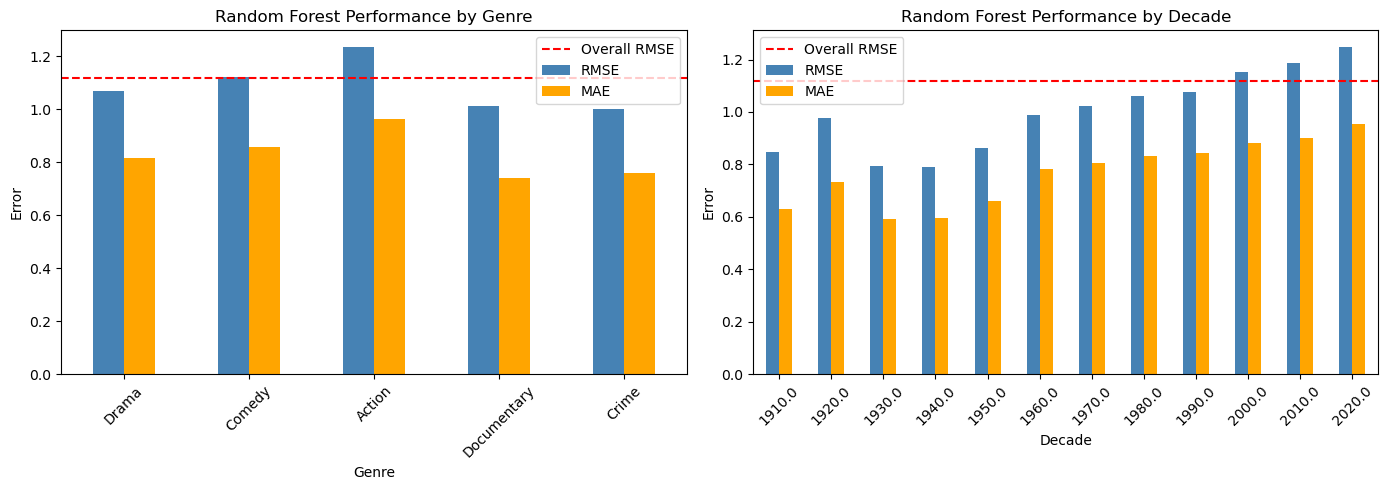

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

genre_df[['RMSE', 'MAE']].plot(kind='bar', ax=axes[0], color=['steelblue', 'orange'])
axes[0].set_title('Random Forest Performance by Genre', fontsize=12)
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Error')
axes[0].axhline(y=1.1191, color='red', linestyle='--', label='Overall RMSE')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

decade_df[['RMSE', 'MAE']].plot(kind='bar', ax=axes[1], color=['steelblue', 'orange'])
axes[1].set_title('Random Forest Performance by Decade', fontsize=12)
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Error')
axes[1].axhline(y=1.1191, color='red', linestyle='--', label='Overall RMSE')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<p dir="rtl">
<strong>מסקנות מניתוח ההוגנות:</strong><br>
מבחינת הגרפים, ניתן לראות כי ביצועי המודל אינם אחידים לחלוטין על פני החתכים השונים:
</p>
<ul dir="rtl">
  <li><strong>הטיית ז'אנר:</strong> המודל מתקשה משמעותית בחיזוי דירוגים של סרטי פעולה (Action), שם השגיאה חורגת מעל קו ה-RMSE הכללי. לעומת זאת, סרטי דרמה ותעודה (Documentary) זוכים לחיזוי מדויק יותר מהממוצע.</li>
  <li><strong>הטיית זמן (עשור):</strong> קיימת מגמה ברורה שבה שגיאת המודל עולה ככל ששנת היציאה של הסרט קרובה יותר לימינו. המודל חוזה בדיוק רב סרטים ישנים (1910-1970), אך מציג שגיאות גבוהות מהממוצע עבור סרטים מהעשורים האחרונים (2010-2020).</li>
</ul>
<p dir="rtl">
ממצאים אלו מצביעים על כך שהמודל "מוטה" קלות לטובת סרטים ישנים וז'אנרים מסוימים, ועשוי לדרוש התאמות עתידיות כדי לשפר את ההוגנות שלו כלפי סרטי אקשן מודרניים.
</p>

<h4 dir="rtl">7. ניתוח חשיבות פיצ'רים (Feature Importance)</h4>
<p dir="rtl">
בסעיף זה נבחן אילו משתנים השפיעו במידה הרבה ביותר על החלטות המודלים שלנו. 
נתחיל עם מודל ה-<code>Elastic Net</code>: נחלץ את 5 הפיצ'רים בעלי המקדמים (Coefficients) הגבוהים ביותר בערכם המוחלט, כדי לזהות מה תרם לחיזוי חיובי או שלילי של הדירוג.
</p>

In [27]:
feature_names = (best_elastic_model.named_steps['preprocess']
                 .get_feature_names_out())

print(f"מספר פיצ'רים סופי: {len(feature_names)}")

מספר פיצ'רים סופי: 39


In [28]:
elastic_coefs = best_elastic_model.named_steps['model'].coef_

elastic_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': elastic_coefs,
    'abs_coefficient': np.abs(elastic_coefs)
}).sort_values('abs_coefficient', ascending=False)

# 5 הפיצ'רים החשובים ביותר
print("5 הפיצ'רים החשובים ביותר ב-Elastic Net:")
top_5_elastic = elastic_importance.head(5).copy()
top_5_elastic['direction'] = top_5_elastic['coefficient'].apply(
    lambda x: 'חיובי' if x > 0 else 'שלילי'
)
display(top_5_elastic[['feature', 'coefficient', 'direction']].round(4))

5 הפיצ'רים החשובים ביותר ב-Elastic Net:


,feature,coefficient,direction
24,cat__primary_genre_Horror,-0.7602,שלילי
5,num__is_documentary,0.4730,חיובי
11,cat__primary_genre_Action,-0.2749,שלילי
1,num__runtimeMinutes,0.2378,חיובי
3,num__is_drama,0.2005,חיובי


<h5 dir="rtl">חשיבות פיצ'רים וכיוון השפעה במודל Random Forest</h5>
<p dir="rtl">
מודל <code>Random Forest</code> מספק מדד לחשיבות הפיצ'ר, אך בניגוד למודל ליניארי, לא מציין את כיוון ההשפעה. לכן, בנוסף לחילוץ חשיבות הפיצ'רים, נחשב קורלציה מול דירוג הסרט האמיתי, כדי להבין האם ההשפעה של הפיצ'רים המובילים היא חיובית או שלילית.
</p>

In [29]:
rf_importances = best_rf_model.named_steps['model'].feature_importances_
rf_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_importances
}).sort_values('importance', ascending=False)

print("5 הפיצ'רים החשובים ביותר ב-Random Forest:")
top_5_rf = rf_importance.head(5).copy()
display(top_5_rf.round(4))

5 הפיצ'רים החשובים ביותר ב-Random Forest:


,feature,importance
5,num__is_documentary,0.3233
1,num__runtimeMinutes,0.1805
3,num__is_drama,0.1796
0,num__startYear,0.0987
24,cat__primary_genre_Horror,0.0889


In [30]:
X_transformed = best_rf_model.named_steps['preprocess'].transform(X)
X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)

correlations = X_transformed_df.corrwith(pd.Series(y.values))

top_5_rf['correlation_with_y'] = top_5_rf['feature'].map(correlations)
top_5_rf['direction'] = top_5_rf['correlation_with_y'].apply(
    lambda x: 'חיובי' if x > 0 else 'שלילי'
)

print("5 הפיצ'רים החשובים ביותר ב-Random Forest (עם כיוון):")
display(top_5_rf[['feature', 'importance', 'correlation_with_y', 'direction']].round(4))

5 הפיצ'רים החשובים ביותר ב-Random Forest (עם כיוון):


,feature,importance,correlation_with_y,direction
5,num__is_documentary,0.3233,0.2965,חיובי
1,num__runtimeMinutes,0.1805,0.1554,חיובי
3,num__is_drama,0.1796,0.1137,חיובי
0,num__startYear,0.0987,-0.0328,שלילי
24,cat__primary_genre_Horror,0.0889,-0.2292,שלילי


<h5 dir="rtl">השוואה ויזואלית של הפיצ'רים המובילים</h5>
<p dir="rtl">
לסיום, נציג בגרפים את 5 הפיצ'רים המשפיעים ביותר בכל אחד מהמודלים, כדי לראות ויזואלית האם המודלים מסתמכים על אותם מאפיינים לצורך החיזוי.
</p>

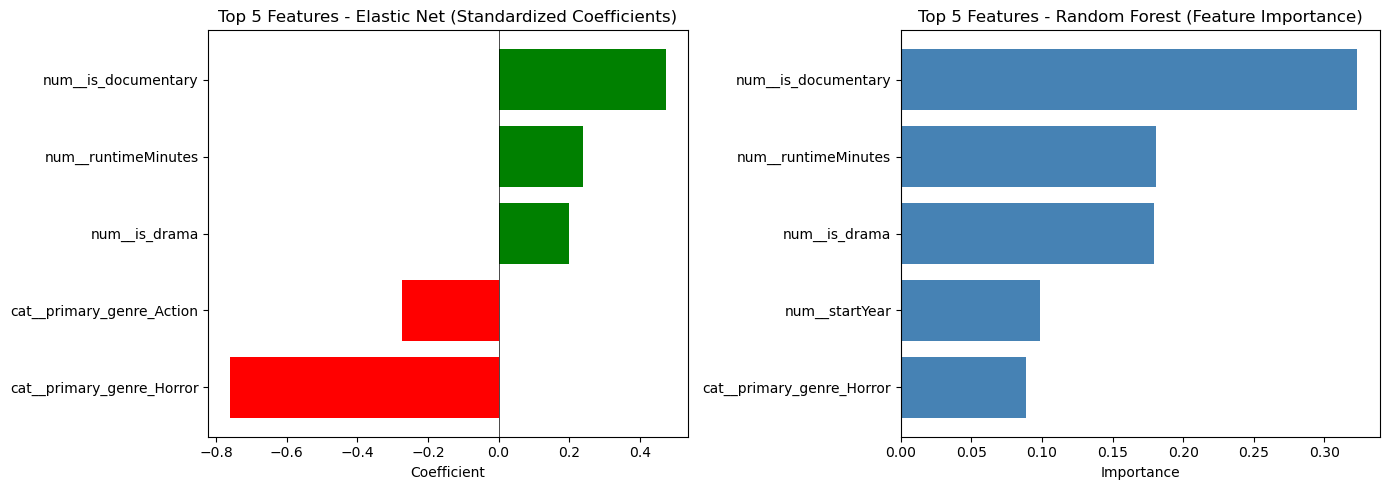

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_5_elastic_sorted = top_5_elastic.sort_values('coefficient')
colors_elastic = ['red' if c < 0 else 'green' for c in top_5_elastic_sorted['coefficient']]
axes[0].barh(top_5_elastic_sorted['feature'], top_5_elastic_sorted['coefficient'],
             color=colors_elastic)
axes[0].set_title('Top 5 Features - Elastic Net (Standardized Coefficients)')
axes[0].set_xlabel('Coefficient')
axes[0].axvline(x=0, color='black', linewidth=0.5)

top_5_rf_sorted = top_5_rf.sort_values('importance')
axes[1].barh(top_5_rf_sorted['feature'], top_5_rf_sorted['importance'],
             color='steelblue')
axes[1].set_title('Top 5 Features - Random Forest (Feature Importance)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

#####  pkl שמירת קובץ

In [33]:
import joblib
best_rf_model.fit(X, y)
joblib.dump(best_rf_model, 'model.pkl')
print("המודל נשמר model.pkl")

המודל נשמר model.pkl
